# Librerias 

In [ ]:
import asyncio
import pandas as pd
import yfinance as yf
import pandas as pd
from tqdm import tqdm

In [ ]:

url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
sp500 = pd.read_csv(url)

tickers_sp500 = [t.replace('.', '-') for t in sp500["Symbol"]]

market_caps = {}

for t in tqdm(tickers_sp500):
    try:
        info = yf.Ticker(t).info
        market_caps[t] = info.get("marketCap", None)
    except:
        market_caps[t] = None

df_caps = pd.DataFrame.from_dict(market_caps, orient='index', columns=['marketCap'])
df_caps = df_caps.dropna().sort_values("marketCap", ascending=False)

# Top 100
acciones_top_100 = df_caps.head(100).index.tolist()
acciones_top_100[:10]


100%|██████████| 503/503 [03:42<00:00,  2.26it/s]


['NVDA',
 'AAPL',
 'MSFT',
 'GOOGL',
 'GOOG',
 'AMZN',
 'AVGO',
 'META',
 'TSLA',
 'BRK-B']

In [29]:
# Índices 
indices = [
    "^GSPC",  # S&P 500
    "^NDX",   # Nasdaq 100
    "^DJI",   # Dow Jones
    "^RUT"    # Russell 2000
]
 
# ETFs 
equity_etfs = [
    "SPY",   # S&P 500
    "QQQ",   # Nasdaq 100
    "IWM",   # Russell 2000
    "EFA",   # EAFE (Europa/Asia desarrollado)
    "EEM"    # Mercados emergentes
]

# Bonos
bond_etfs = [
    "IEF",  # Bonos del tesoro 7-10 años
    "TLT",  # Bonos del tesoro 20+ años
    "SHY"   # Letras 1-3 años
]

# Comomodities
commodities = [
    "GC=F",   # Oro
    "SI=F",   # Plata
    "CL=F",   # Crudo WTI
    "NG=F"    # Gas natural
]

In [19]:
from datetime import datetime, timedelta

fecha_fin = datetime.now()
fecha_inicio = fecha_fin - timedelta(days=30 * 365)

In [23]:
async def descargar_accion(ticker):
    loop = asyncio.get_event_loop()

    df = await loop.run_in_executor(
        None,
        lambda: yf.download(
            ticker,
            start=fecha_inicio,
            end=fecha_fin,
            interval="1d",
            auto_adjust=True
        )
    )

    df = df.reset_index()

    # --- FIX: asegurar que Close sea 1D ---
    if isinstance(df['Close'], pd.DataFrame):
        close = df['Close'].iloc[:, 0]
    else:
        close = df['Close']

    date = df['Date']

    df_simple = pd.DataFrame({
        "Date": date,
        "Close": close,
        "Ticker": ticker
    })

    df_simple["Return"] = df_simple["Close"].pct_change()
    df_simple = df_simple.dropna().reset_index(drop=True)

    print(f"Descargado {ticker}: {len(df_simple)} registros")
    return df_simple


In [31]:
activos_extra = (
    indices +
    equity_etfs +
    bond_etfs +
    commodities
)

lista_activos_totales = acciones_top_100 + activos_extra
len(lista_activos_totales)

116

In [32]:
async def descargar_todos():
    resultados = []
    for t in lista_activos_totales:
        out = await descargar_accion(t)
        resultados.append(out)
        await asyncio.sleep(0.2)
    return resultados

dfs = await descargar_todos()


Descargado NVDA: 6747 registros
Descargado AAPL: 7543 registros
Descargado MSFT: 7543 registros
Descargado GOOGL: 5346 registros
Descargado GOOG: 5346 registros
Descargado AMZN: 7172 registros
Descargado AVGO: 4096 registros
Descargado META: 3394 registros
Descargado TSLA: 3871 registros
Descargado BRK-B: 7429 registros
Descargado LLY: 7543 registros
Descargado JPM: 7543 registros
Descargado WMT: 7543 registros
Descargado V: 4445 registros
Descargado ORCL: 7543 registros
Descargado XOM: 7543 registros
Descargado MA: 4901 registros
Descargado JNJ: 7543 registros
Descargado NFLX: 5910 registros
Descargado ABBV: 3239 registros
Descargado PLTR: 1289 registros
Descargado COST: 7543 registros
Descargado AMD: 7543 registros
Descargado BAC: 7543 registros
Descargado HD: 7543 registros
Descargado PG: 7543 registros
Descargado GE: 7543 registros
Descargado CVX: 7543 registros
Descargado CSCO: 7543 registros
Descargado KO: 7543 registros
Descargado UNH: 7543 registros
Descargado IBM: 7543 registr

In [33]:
datos_acciones = pd.concat(dfs, ignore_index=True)
datos_acciones = datos_acciones.sort_values(["Date", "Ticker"]).reset_index(drop=True)

datos_acciones.head()

,Date,Close,Ticker,Return
0,1995-11-28,0.299911,AAPL,0.015872
1,1995-11-28,4.401172,ABT,-0.006098
2,1995-11-28,8.380190,ADBE,0.057692
3,1995-11-28,5.286075,ADI,0.057692
4,1995-11-28,4.196064,AMAT,0.097923


In [34]:
aapl = datos_acciones[ datos_acciones["Ticker"] == "AAPL" ]
aapl.head()

,Date,Close,Ticker,Return
0,1995-11-28,0.299911,AAPL,0.015872
75,1995-11-29,0.294287,AAPL,-0.018751
150,1995-11-30,0.285852,AAPL,-0.028661
225,1995-12-01,0.282104,AAPL,-0.013114
300,1995-12-04,0.296162,AAPL,0.049834


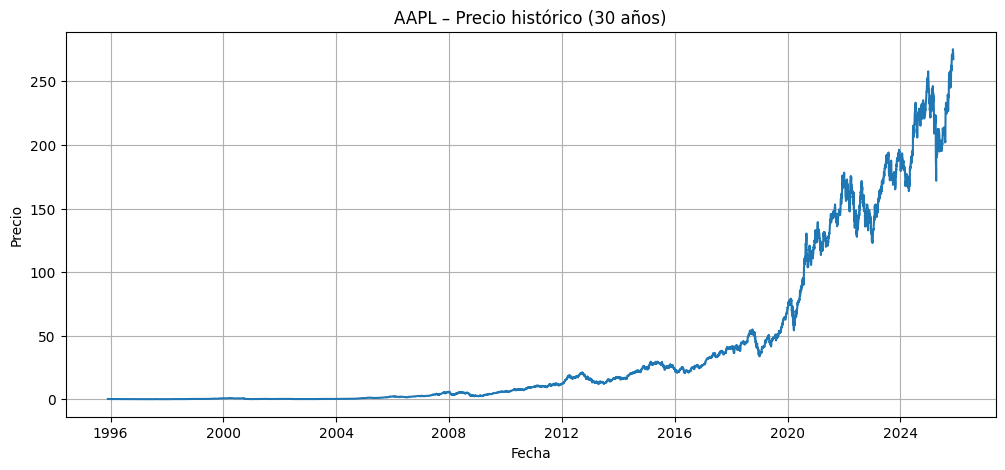

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(aapl["Date"], aapl["Close"])
plt.title("AAPL – Precio histórico (30 años)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid(True)
plt.show()


Pivotear los precios 

In [37]:
precios = datos_acciones.pivot(index="Date", columns="Ticker", values="Close").sort_index()
retornos = precios.pct_change()

C:\Users\ENRIQUE\AppData\Local\Temp\ipykernel_26576\2753448752.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = precios.pct_change()


In [39]:
# Retornos diarios
ret_1d = retornos

# Retornos acumulados
ret_5d = precios.pct_change(5)
ret_20d = precios.pct_change(20)

# Volatilidad rolling
vol_5d = retornos.rolling(5).std()
vol_20d = retornos.rolling(20).std()

# Medias móviles
ma_5 = precios.rolling(5).mean()
ma_20 = precios.rolling(20).mean()

# Distancias a medias móviles
dist_ma_5 = (precios - ma_5) / ma_5
dist_ma_20 = (precios - ma_20) / ma_20

# Concatenar todo con MULTI-INDEX
features_stacked = pd.concat(
    {
        "ret_1d": ret_1d,
        "ret_5d": ret_5d,
        "ret_20d": ret_20d,
        "vol_5d": vol_5d,
        "vol_20d": vol_20d,
        "ma_5": ma_5,
        "ma_20": ma_20,
        "dist_ma_5": dist_ma_5,
        "dist_ma_20": dist_ma_20,
    },
    axis=1
)


C:\Users\ENRIQUE\AppData\Local\Temp\ipykernel_26576\4069226071.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_5d = precios.pct_change(5)
C:\Users\ENRIQUE\AppData\Local\Temp\ipykernel_26576\4069226071.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret_20d = precios.pct_change(20)


In [40]:
features_long = (
    features_stacked
    .stack(level=1)
    .reset_index()
    .rename(columns={"level_1": "Ticker"})
)


C:\Users\ENRIQUE\AppData\Local\Temp\ipykernel_26576\3627662511.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level=1)


In [42]:
df_final = datos_acciones.merge(features_long, on=["Date", "Ticker"], how="left")
df_final.head()

,Date,Close,Ticker,Return,ret_1d,ret_5d,ret_20d,vol_5d,vol_20d,ma_5,ma_20,dist_ma_5,dist_ma_20
0,1995-11-28,0.299911,AAPL,0.015872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1995-11-28,4.401172,ABT,-0.006098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1995-11-28,8.380190,ADBE,0.057692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1995-11-28,5.286075,ADI,0.057692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1995-11-28,4.196064,AMAT,0.097923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
df_final.to_csv("features_financieras.csv", index=False)